# Phase 3 — Heterogeneous Graph Construction 
**Input:** `Dataset/Processed/features.csv` (output from Phase 2)  
**Output:** `Dataset/Processed/graph_data.pt` (PyTorch Geometric HeteroData object)  

**What this notebook does:**
1. Load the feature matrix from Phase 2
2. Define 3 node types: User, IP, Service
3. Define 2 edge types: User→IP (`accesses`), User→Service (`calls`)
4. Build a `HeteroData` object with node features and edge indices
5. Attach anomaly labels to User nodes
6. Verify and visualize the graph structure
7. Save the graph object for Phase 4

## Cell 1 — Install Dependencies
Run this cell once if you have not installed PyTorch Geometric yet.  
After installation, **restart the kernel** before continuing.

In [8]:
# Only run this once. Comment it out after first successful install.
import sys

# Install PyTorch Geometric and its dependencies
!{sys.executable} -m pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu
!{sys.executable} -m pip install torch_geometric
!{sys.executable} -m pip install networkx matplotlib

print("Installation complete. RESTART YOUR KERNEL before running Cell 2 onwards.")

Looking in indexes: https://download.pytorch.org/whl/cpu

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Installation complete. RESTART YOUR KERNEL before running Cell 2 onwards.


## Cell 2 — Imports & Load Data

In [9]:
import pandas as pd
import numpy as np
import torch
from torch_geometric.data import HeteroData
import networkx as nx
import matplotlib.pyplot as plt
import os


# update these paths to match your local setup
INPUT_PATH = os.path.expanduser("~/Downloads/federated-hgnn-anomaly-detection/Dataset/Processed/features.csv")
OUTPUT_PATH = os.path.expanduser("~/Downloads/federated-hgnn-anomaly-detection/Dataset/Processed/graph_data.pt")

df = pd.read_csv(INPUT_PATH)
print("Loaded shape:", df.shape)
print("Columns:", df.columns.tolist())

Loaded shape: (2900, 15)
Columns: ['userName_enc', 'sourceIPAddress_enc', 'eventSource_enc', 'eventName_enc', 'type_enc', 'sessionContext.attributes.mfaAuthenticated_enc', 'errorCode_enc', 'readOnly_enc', 'action_count', 'unique_ips', 'unique_services', 'unique_events', 'error_rate', 'readonly_ratio', 'is_anomaly']


## Cell 3 — Build Node ID Mappings
Each unique User, IP, and Service gets a contiguous integer ID starting from 0.  
This is required by PyTorch Geometric — edge indices must reference these integer IDs.

Graph schema:
- **Node types:** User (identity), IP (network bridge), Service (target/eventSource)
- **Edge types:** User →[accesses]→ IP, User →[calls]→ Service

In [10]:
# Re-read from phase 1 output to get original string columns for node mapping
PHASE1_PATH = os.path.expanduser("~/Downloads/federated-hgnn-anomaly-detection/Dataset/Processed/df_identity_clean.csv")
df_raw = pd.read_csv(PHASE1_PATH)

df.describe()

,userName_enc,sourceIPAddress_enc,eventSource_enc,eventName_enc,type_enc,sessionContext.attributes.mfaAuthenticated_enc,errorCode_enc,readOnly_enc,action_count,unique_ips,unique_services,unique_events,error_rate,readonly_ratio,is_anomaly
count,2900.000000,2900.000000,2900.000000,2900.000000,2900.000000,2900.000000,2900.000000,2900.000000,2900.000000,2900.000000,2900.000000,2900.000000,2900.000000,2900.000000,2900.000000
mean,1.859310,4.622414,14.059655,130.879655,1.964828,0.355862,20.171034,0.802069,0.915457,0.570613,0.928077,0.918209,0.334674,0.802069,0.041379
std,0.475911,2.525041,8.860552,63.372743,0.293903,0.690134,3.289062,0.398509,0.270602,0.109659,0.230225,0.261786,0.158718,0.066606,0.199200
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,4.000000,5.000000,86.000000,2.000000,0.000000,20.000000,1.000000,1.000000,0.555556,1.000000,1.000000,0.292691,0.807721,0.000000
50%,2.000000,4.000000,10.000000,124.000000,2.000000,0.000000,20.000000,1.000000,1.000000,0.555556,1.000000,1.000000,0.292691,0.807721,0.000000
75%,2.000000,4.000000,23.000000,186.000000,2.000000,0.000000,20.000000,1.000000,1.000000,0.555556,1.000000,1.000000,0.292691,0.807721,0.000000
max,3.000000,15.000000,28.000000,259.000000,3.000000,2.000000,32.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [11]:
# Build unique node sets
unique_users = df_raw['userName'].dropna().unique()
unique_ips = df_raw['sourceIPAddress'].dropna().unique()
unique_services = df_raw['eventSource'].dropna().unique()

print(f"Unique Users ({len(unique_users)}):")
print("\n".join([str(u) for u in unique_users]))

print(f"\nUnique IPs ({len(unique_ips)}):")
print("\n".join([str(i) for i in unique_ips]))

print(f"\nUnique Services ({len(unique_services)}):")
print("\n".join([str(s) for s in unique_services]))

Unique Users (4):
bert-jan
Unknown
benjamin
stratus-red-team-nmfalu-gfjyeaypjt

Unique IPs (16):
192.168.10.20
cloudtrail.amazonaws.com
AWS Internal
10.248.16.43
10.107.112.14
health.amazonaws.com
10.8.8.10
rds.amazonaws.com
3.225.16.109
lambda.amazonaws.com
rolesanywhere.amazonaws.com
inspector2.amazonaws.com
ec2.amazonaws.com
secretsmanager.amazonaws.com
52.45.102.28
10.107.159.90

Unique Services (29):
iam.amazonaws.com
ec2.amazonaws.com
sts.amazonaws.com
s3.amazonaws.com
secretsmanager.amazonaws.com
kms.amazonaws.com
ssm.amazonaws.com
cloudtrail.amazonaws.com
logs.amazonaws.com
account.amazonaws.com
health.amazonaws.com
notifications.amazonaws.com
route53resolver.amazonaws.com
ram.amazonaws.com
ce.amazonaws.com
rds.amazonaws.com
lambda.amazonaws.com
rolesanywhere.amazonaws.com
resource-explorer-2.amazonaws.com
securityhub.amazonaws.com
guardduty.amazonaws.com
servicecatalog-appregistry.amazonaws.com
signin.amazonaws.com
monitoring.amazonaws.com
devops-guru.amazonaws.com
autoscaling

In [12]:
# Create string -> integer mappings
user_to_id = {name: idx for idx, name in enumerate(unique_users)}
ip_to_id = {ip: idx for idx, ip in enumerate(unique_ips)}
service_to_id = {svc: idx for idx, svc in enumerate(unique_services)}


print(f"Node counts:")
print(f"  User nodes:    {len(user_to_id)}")
print(f"  IP nodes:      {len(ip_to_id)}")
print(f"  Service nodes: {len(service_to_id)}")

print(f"\nUser node IDs:")
for name, idx in user_to_id.items():
    print(f"  [{idx}] {name}")

print(f"\nService node IDs:")
for svc, idx in service_to_id.items():
    print(f"  [{idx}] {svc}")

Node counts:
  User nodes:    4
  IP nodes:      16
  Service nodes: 29

User node IDs:
  [0] bert-jan
  [1] Unknown
  [2] benjamin
  [3] stratus-red-team-nmfalu-gfjyeaypjt

Service node IDs:
  [0] iam.amazonaws.com
  [1] ec2.amazonaws.com
  [2] sts.amazonaws.com
  [3] s3.amazonaws.com
  [4] secretsmanager.amazonaws.com
  [5] kms.amazonaws.com
  [6] ssm.amazonaws.com
  [7] cloudtrail.amazonaws.com
  [8] logs.amazonaws.com
  [9] account.amazonaws.com
  [10] health.amazonaws.com
  [11] notifications.amazonaws.com
  [12] route53resolver.amazonaws.com
  [13] ram.amazonaws.com
  [14] ce.amazonaws.com
  [15] rds.amazonaws.com
  [16] lambda.amazonaws.com
  [17] rolesanywhere.amazonaws.com
  [18] resource-explorer-2.amazonaws.com
  [19] securityhub.amazonaws.com
  [20] guardduty.amazonaws.com
  [21] servicecatalog-appregistry.amazonaws.com
  [22] signin.amazonaws.com
  [23] monitoring.amazonaws.com
  [24] devops-guru.amazonaws.com
  [25] autoscaling.amazonaws.com
  [26] elasticloadbalancing.am

## Cell 4 — Build Node Feature Tensors
Each node type needs a feature matrix of shape `[num_nodes, num_features]`.  
- **User nodes** get the behavioral profile features from Phase 2 (action_count, error_rate, etc.)
- **IP nodes** get a simple one-hot-style feature: how many times they appear in the logs
- **Service nodes** get a frequency count feature as well

In [13]:
# USER NODE FEATURES
# The behavioral profile columns from Phase 2
USER_FEATURE_COLS = [
    'action_count',
    'unique_ips',
    'unique_services',
    'unique_events',
    'error_rate',
    'readonly_ratio',
]

# Aggregate per user (all rows for same user have same profile values — just take first)
user_features_df = df.merge(
    pd.DataFrame({'userName': list(user_to_id.keys()), 'user_node_id': list(user_to_id.values())}),
    left_on='userName_enc',
    right_on='user_node_id',
    how='left'
)

# Get one feature row per user, ordered by user_node_id
# We do this by taking the first occurrence of each userName_enc value
user_feat_matrix = (
    df.groupby('userName_enc')[USER_FEATURE_COLS]
    .first()
    .sort_index()
    .values
)
x_user = torch.tensor(user_feat_matrix, dtype=torch.float)
print(f"x_user:", x_user)
print(f"User feature tensor shape: {x_user.shape}  (num_users x num_features)")

# IP NODE FEATURES
# Feature: normalized access frequency
ip_counts = df_raw['sourceIPAddress'].value_counts()
ip_freq = np.array([
    ip_counts.get(ip, 0) for ip in unique_ips
], dtype=np.float32)

ip_freq = ip_freq / ip_freq.max()  # normalize to [0, 1]
x_ip = torch.tensor(ip_freq.reshape(-1, 1), dtype=torch.float)
print(f"x_ip:", x_ip)
print(f"IP feature tensor shape:   {x_ip.shape}  (num_ips x 1)")

# SERVICE NODE FEATURES
# Feature: normalized call frequency
svc_counts = df_raw['eventSource'].value_counts()
svc_freq = np.array([
    svc_counts.get(svc, 0) for svc in unique_services
], dtype=np.float32)

svc_freq = svc_freq / svc_freq.max()  # normalize to [0, 1]
x_service = torch.tensor(svc_freq.reshape(-1, 1), dtype=torch.float)
print(f"x_service:", x_service)
print(f"Service feature tensor:    {x_service.shape}  (num_services x 1)")

x_user: tensor([[0.0572, 1.0000, 0.1923, 0.0826, 1.0000, 0.5724],
        [0.0394, 0.3333, 0.1923, 0.0785, 0.4311, 1.0000],
        [1.0000, 0.5556, 1.0000, 1.0000, 0.2927, 0.8077],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000]])
User feature tensor shape: torch.Size([4, 6])  (num_users x num_features)
x_ip: tensor([[1.0000e+00],
        [3.7140e-03],
        [7.8923e-02],
        [4.1318e-02],
        [4.6425e-04],
        [1.1606e-02],
        [1.3045e-01],
        [6.4995e-03],
        [6.0353e-03],
        [9.2851e-04],
        [2.7855e-03],
        [2.7855e-03],
        [2.7855e-03],
        [5.3853e-02],
        [3.7140e-03],
        [4.6425e-04]])
IP feature tensor shape:   torch.Size([16, 1])  (num_ips x 1)
x_service: tensor([[0.4462],
        [1.0000],
        [0.0717],
        [0.3038],
        [0.2612],
        [0.2691],
        [0.5471],
        [0.0392],
        [0.0067],
        [0.0034],
        [0.0538],
        [0.0090],
        [0.0011],
        [0.0022],
 

In [14]:
# Viewing User Features with column names
user_view = pd.DataFrame(x_user.numpy(), columns=USER_FEATURE_COLS)
print("User Feature Matrix:")
print(user_view)

# Viewing IP and Service Features
# Since these only have 1 column, we can just label it 'frequency'
ip_view = pd.DataFrame(x_ip.numpy(), columns=['normalized_freq'])
print("\nIP Feature Matrix (First 5):")
print(ip_view.head())

# Create a DataFrame using the list of unique services as the index
service_view = pd.DataFrame(
    x_service.numpy(), 
    index=unique_services, 
    columns=['normalized_usage_freq']
)

# Sort by usage to see the most accessed services at the top
print("Service Node Feature View (Top 10):")
print(service_view.sort_values(by='normalized_usage_freq', ascending=False).head(10))

User Feature Matrix:
   action_count  unique_ips  unique_services  unique_events  error_rate  \
0      0.057175    1.000000         0.192308       0.082645    1.000000   
1      0.039379    0.333333         0.192308       0.078512    0.431113   
2      1.000000    0.555556         1.000000       1.000000    0.292691   
3      0.000000    0.000000         0.000000       0.000000    0.000000   

   readonly_ratio  
0        0.572368  
1        1.000000  
2        0.807721  
3        0.000000  

IP Feature Matrix (First 5):
   normalized_freq
0         1.000000
1         0.003714
2         0.078923
3         0.041318
4         0.000464
Service Node Feature View (Top 10):
                              normalized_usage_freq
ec2.amazonaws.com                          1.000000
ssm.amazonaws.com                          0.547085
iam.amazonaws.com                          0.446188
s3.amazonaws.com                           0.303812
kms.amazonaws.com                          0.269058
secretsmana

## Cell 5 — Build Edge Index Tensors
Edges are stored as a tensor of shape `[2, num_edges]`.  
Row 0 = source node IDs, Row 1 = destination node IDs.  
Each row in the event log becomes one edge (or two — one User→IP, one User→Service).

In [15]:
# Map raw string values to node integer IDs
df_raw['user_node_id'] = df_raw['userName'].map(user_to_id)
df_raw['ip_node_id'] = df_raw['sourceIPAddress'].map(ip_to_id)
df_raw['service_node_id'] = df_raw['eventSource'].map(service_to_id)

# Drop rows where any mapping failed (shouldn't happen, but safety check)
df_edges = df_raw.dropna(subset=['user_node_id', 'ip_node_id', 'service_node_id']).copy()
df_edges = df_edges.astype({'user_node_id': int, 'ip_node_id': int, 'service_node_id': int})

# EDGE TYPE 1: User -> IP (user accesses IP)
user_ip_src = torch.tensor(df_edges['user_node_id'].values, dtype=torch.long)
user_ip_dst = torch.tensor(df_edges['ip_node_id'].values,   dtype=torch.long)
edge_index_user_ip = torch.stack([user_ip_src, user_ip_dst], dim=0)

# EDGE TYPE 2: User -> Service (user calls service)
user_svc_src = torch.tensor(df_edges['user_node_id'].values,    dtype=torch.long)
user_svc_dst = torch.tensor(df_edges['service_node_id'].values, dtype=torch.long)
edge_index_user_svc = torch.stack([user_svc_src, user_svc_dst], dim=0)

print(f"Edge type User->IP:      {edge_index_user_ip.shape}   (2 x num_edges)")
print(f"Edge type User->Service: {edge_index_user_svc.shape}   (2 x num_edges)")
print(f"Total edges: {edge_index_user_ip.shape[1] + edge_index_user_svc.shape[1]}")

Edge type User->IP:      torch.Size([2, 2900])   (2 x num_edges)
Edge type User->Service: torch.Size([2, 2900])   (2 x num_edges)
Total edges: 5800


## Cell 6 — Attach Anomaly Labels to User Nodes
Labels are attached at the **User node level**, not the edge level.  
A user is labeled anomalous (1) if any of their events was flagged in Phase 1.

In [16]:
# Get max anomaly label per user, ordered by user_node_id
user_labels = (
    df_raw.groupby('user_node_id')['is_anomaly']
    .max()
    .sort_index()
    .values
)
y_user = torch.tensor(user_labels, dtype=torch.long)

print("User node labels:")
for name, uid in user_to_id.items():
    label = y_user[uid].item()
    status = 'ANOMALY' if label == 1 else 'Normal'
    print(f"  [{uid}] {name:45s} -> {status}")

print(f"\nLabel tensor shape: {y_user.shape}")

User node labels:
  [0] bert-jan                                      -> ANOMALY
  [1] Unknown                                       -> ANOMALY
  [2] benjamin                                      -> Normal
  [3] stratus-red-team-nmfalu-gfjyeaypjt            -> Normal

Label tensor shape: torch.Size([4])


## Cell 7 — Assemble HeteroData Object
This is the final graph object that will be fed into the HGNN model in Phase 4.  
It follows the PyTorch Geometric `HeteroData` format.

In [20]:
graph = HeteroData()

# Node features
graph['user'].x = x_user
graph['ip'].x = x_ip
graph['service'].x = x_service

# Node labels (only User nodes have labels for classification)
graph['user'].y = y_user

# Edge indices
# Naming convention in PyG: ('src_type', 'relation', 'dst_type')
graph['user', 'accesses', 'ip'].edge_index = edge_index_user_ip
graph['user', 'calls', 'service'].edge_index = edge_index_user_svc

# Reverse Edges
graph['ip', 'accessed_by', 'user'].edge_index = edge_index_user_ip.flip([0])
graph['service', 'called_by', 'user'].edge_index = edge_index_user_svc.flip([0])

# Summary
print("HeteroData graph summary:")
print(graph)
print()
print(f"User node feature shape:    {graph['user'].x.shape}")
print(f"IP node feature shape:      {graph['ip'].x.shape}")
print(f"Service node feature shape: {graph['service'].x.shape}")
print(f"User labels shape:          {graph['user'].y.shape}")
print(f"User->IP edges:             {graph['user', 'accesses', 'ip'].edge_index.shape}")
print(f"User->Service edges:        {graph['user', 'calls', 'service'].edge_index.shape}")

HeteroData graph summary:
HeteroData(
  user={
    x=[4, 6],
    y=[4],
  },
  ip={ x=[16, 1] },
  service={ x=[29, 1] },
  (user, accesses, ip)={ edge_index=[2, 2900] },
  (user, calls, service)={ edge_index=[2, 2900] },
  (ip, accessed_by, user)={ edge_index=[2, 2900] },
  (service, called_by, user)={ edge_index=[2, 2900] }
)

User node feature shape:    torch.Size([4, 6])
IP node feature shape:      torch.Size([16, 1])
Service node feature shape: torch.Size([29, 1])
User labels shape:          torch.Size([4])
User->IP edges:             torch.Size([2, 2900])
User->Service edges:        torch.Size([2, 2900])


## Cell 8 — Validate Graph
PyTorch Geometric has a built-in validator. Any error here must be fixed before Phase 4.

In [21]:
from torch_geometric.utils import to_networkx

# Built-in PyG validation
# This checks: edge indices are within bounds, no negative indices, etc.
try:
    graph.validate(raise_on_error=True)
    print("Graph validation PASSED. No structural errors found.")
except Exception as e:
    print(f"Graph validation FAILED: {e}")

# Check node/edge counts manually
print(f"\nNode counts:")
print(f"  user:    {graph['user'].num_nodes}")
print(f"  ip:      {graph['ip'].num_nodes}")
print(f"  service: {graph['service'].num_nodes}")
print(f"\nEdge counts:")
print(f"  user->ip:      {graph['user', 'accesses', 'ip'].num_edges}")
print(f"  user->service: {graph['user', 'calls', 'service'].num_edges}")

# Confirm max edge index doesn't exceed node count (most common bug)
max_user_in_ip_edges  = edge_index_user_ip[0].max().item()
max_user_in_svc_edges = edge_index_user_svc[0].max().item()
print(f"\nMax user index in User->IP edges:      {max_user_in_ip_edges}  (should be < {len(user_to_id)})")
print(f"Max user index in User->Service edges: {max_user_in_svc_edges}  (should be < {len(user_to_id)})")

# Check label distribution in the graph
labels = graph['user'].y
unique, counts = labels.unique(return_counts=True)
label_dist = dict(zip(unique.tolist(), counts.tolist()))

print(f"\nGraph Label Distribution (User nodes):")
print(f"  Normal (0):  {label_dist.get(0, 0)}")
print(f"  Anomaly (1): {label_dist.get(1, 0)}")

Graph validation PASSED. No structural errors found.

Node counts:
  user:    4
  ip:      16
  service: 29

Edge counts:
  user->ip:      2900
  user->service: 2900

Max user index in User->IP edges:      3  (should be < 4)
Max user index in User->Service edges: 3  (should be < 4)

Graph Label Distribution (User nodes):
  Normal (0):  2
  Anomaly (1): 2


## Cell 9 — Visualize Graph with NetworkX
This renders a simplified view of the graph to confirm the structure visually.  
Red nodes = anomalous users. Blue = normal users. Orange = IP nodes. Green = Service nodes.

Created directory: /Users/philberttan/Downloads/Pre Thesis/Dataset/Processed/


/var/folders/s5/ck6frb1j5sq98srb5ml9wg9m0000gn/T/ipykernel_49249/2179926872.py:66: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


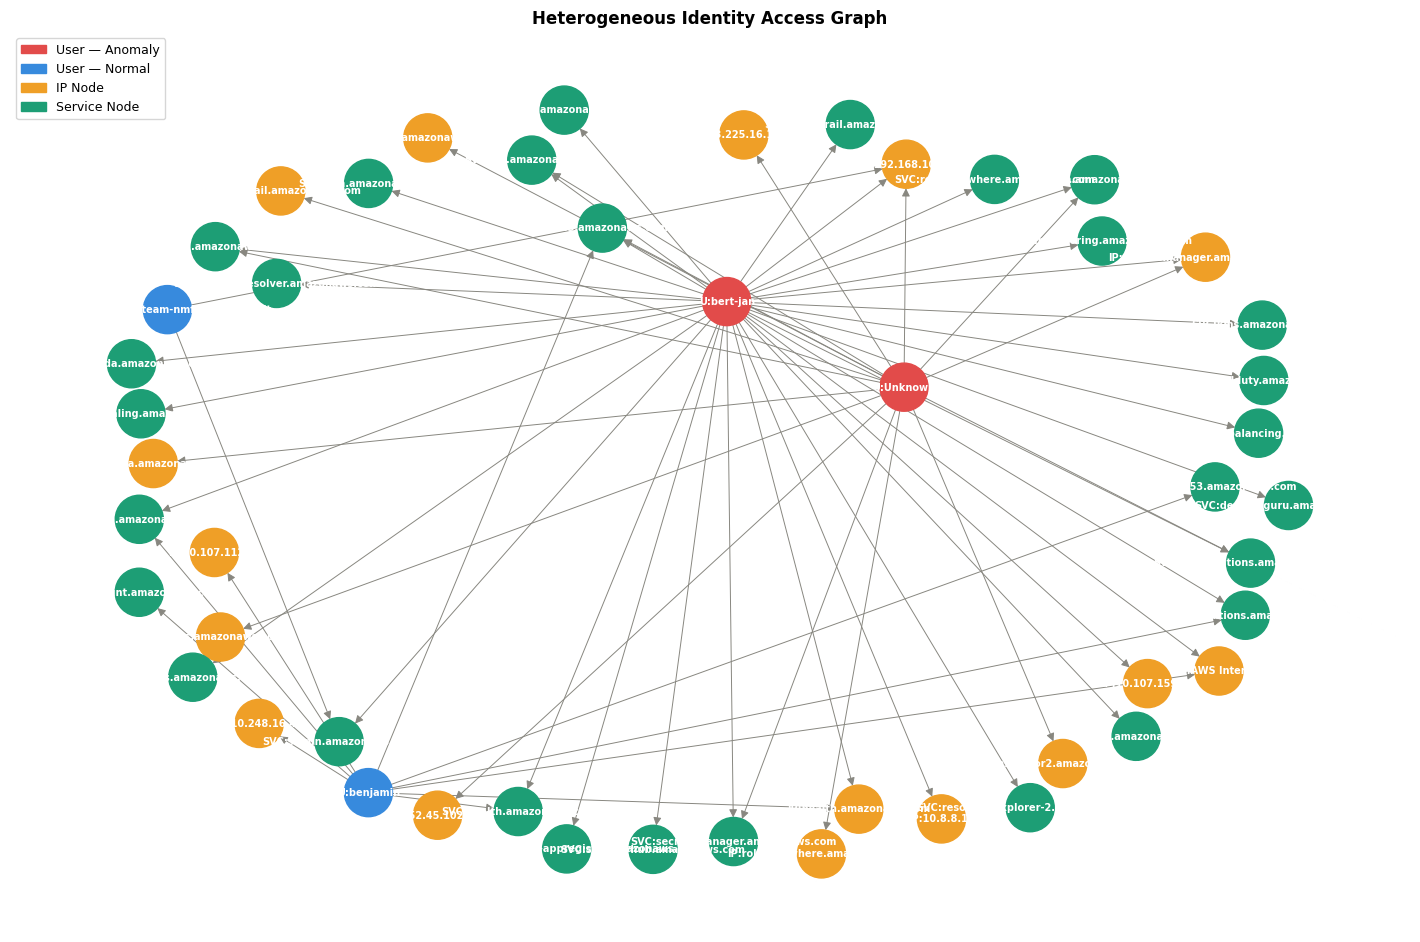

Graph visualization saved.


In [23]:
G = nx.DiGraph()

# Define the directory path
save_dir = os.path.expanduser("~/Downloads/Pre Thesis/Dataset/Processed/")

# Check if the directory exists
if not os.path.exists(save_dir):
    os.makedirs(save_dir)
    print(f"Created directory: {save_dir}")
# Add User nodes
for name, uid in user_to_id.items():
    label = y_user[uid].item()
    G.add_node(f"U:{name}", node_type='user', anomaly=label)

# Add IP nodes
for ip, iid in ip_to_id.items():
    G.add_node(f"IP:{ip}", node_type='ip')

# Add Service nodes
for svc, sid in service_to_id.items():
    G.add_node(f"SVC:{svc}", node_type='service')

# Add edges (deduplicated for visualization clarity)
for _, row in df_raw[['userName', 'sourceIPAddress', 'eventSource']].drop_duplicates().iterrows():
    G.add_edge(f"U:{row['userName']}",      f"IP:{row['sourceIPAddress']}",   edge_type='accesses')
    G.add_edge(f"U:{row['userName']}",      f"SVC:{row['eventSource']}",      edge_type='calls')

# Assign colors per node type
color_map = []
for node in G.nodes(data=True):
    ntype = node[1].get('node_type')
    if ntype == 'user':
        color_map.append('#E24B4A' if node[1].get('anomaly') == 1 else '#378ADD')
    elif ntype == 'ip':
        color_map.append('#EF9F27')
    else:
        color_map.append('#1D9E75')

plt.figure(figsize=(14, 9))
pos = nx.spring_layout(G, seed=42, k=2.5)
nx.draw(
    G, pos,
    node_color=color_map,
    with_labels=True,
    labels={n: n for n in G.nodes()},
    node_size=1200,
    font_size=7,
    font_color='white',
    font_weight='bold',
    arrows=True,
    arrowsize=12,
    edge_color='#888780',
    width=0.7,
)

# Legend
from matplotlib.patches import Patch
legend = [
    Patch(color='#E24B4A', label='User — Anomaly'),
    Patch(color='#378ADD', label='User — Normal'),
    Patch(color='#EF9F27', label='IP Node'),
    Patch(color='#1D9E75', label='Service Node'),
]
plt.legend(handles=legend, loc='upper left', fontsize=9)
plt.title("Heterogeneous Identity Access Graph", fontsize=12, fontweight='bold')
plt.tight_layout()
save_path = os.path.join(save_dir, "graph_visualization.png")
plt.show()
print("Graph visualization saved.")

## Cell 10 — Save Graph Object

In [24]:
os.makedirs(os.path.dirname(OUTPUT_PATH), exist_ok=True)

torch.save(graph, OUTPUT_PATH)

# Verify it can be loaded back correctly
graph_check = torch.load(OUTPUT_PATH, weights_only=False)
print("Save and reload verification:")
print(graph_check)
print(f"\nSaved to: {OUTPUT_PATH}")
print("Phase 3 complete. Ready for Phase 4 — HGNN Model.")

Save and reload verification:
HeteroData(
  user={
    x=[4, 6],
    y=[4],
  },
  ip={ x=[16, 1] },
  service={ x=[29, 1] },
  (user, accesses, ip)={ edge_index=[2, 2900] },
  (user, calls, service)={ edge_index=[2, 2900] },
  (ip, accessed_by, user)={ edge_index=[2, 2900] },
  (service, called_by, user)={ edge_index=[2, 2900] }
)

Saved to: /Users/philberttan/Downloads/federated-hgnn-anomaly-detection/Dataset/Processed/graph_data.pt
Phase 3 complete. Ready for Phase 4 — HGNN Model.
